# Household Transmission Epidemic Model

**1.  Master Equations in household transmission model**


a. Background



We will develop a household transmission model to simulate the probability of different transmission states for each household size using master equations. The state (s, i, r, n) represents the number of susceptible, infectious, and recovered individuals in a household whose size is n. The model simulates the change of state given a household size, dX(s,i,r | n)/dt considering transmission rates within a household and between households.   



The SIR system for household transmission involves considering interactions both within households (i.e. individuals in the same house) and between households (i.e. interactions between individuals from different households).

Specifically, the key variables we will use are:
  *   K: Number of households.
  *   N: Total population.
  *   S, I, R: Total number of susceptible, infectious, and recovered individuals across all households.
  *   n: Number of individuals in one house.
  *   s, i, r: Number of susceptible, infectious, and recovered individuals in a single household.
  *   βc: Infection rate due to transmission between households.
  *   βh: Infection rate due to transmission within a household.
  *   ɑ: Recovery rate of infectious individuals.
  *   (s,i,r,n): State expression.

   Relations: s+i+r=n, S+I+R=N



  b. Master Equations for a single household with n individuals:





\begin{aligned}
&\frac{ds}{dt} = - \left( \beta_c \frac{S}{N} + \beta_h \frac{s}{n} \frac{i}{n} \right) \\[10pt]
&\frac{di}{dt} = \beta_c \frac{S}{N} \frac{I}{N} + \beta_h \frac{s}{n} \frac{i}{n} - \alpha i \\[10pt]
&\frac{dr}{dt} = \alpha i
\end{aligned}

Explanation:

\begin{aligned}
&\beta_c \frac{S}{N}\frac{I}{N} && \text{: Infection dut to transmission between households.} \\[5pt]
&\beta_h \frac{s}{n}\frac{i}{n} && \text{: Infection due to transmission among people in the same house.} \\[5pt]
&\alpha i && \text{: Recovery of infectious individuals.}
\end{aligned}

c. Master Equations for the entire population:

For the entire population across K households, we sum the individual contributions of each household.



\begin{aligned}
&S = \sum_{k=1}^{K} s_k, \quad
&I = \sum_{k=1}^{K} i_k, \quad
&R = \sum_{k=1}^{K} r_k
\end{aligned}



\begin{aligned}
&\frac{dS}{dt} = \sum_{k=1}^{K} \frac{ds_k}{dt} = -\sum_{k=1}^{K} \left( \beta_c \frac{S}{N} \frac{I}{N} + \beta_h \frac{s_k}{n_k} \frac{i_k}{n_k} \right) = -\left( K \beta_c \frac{S}{N} \frac{I}{N} + \sum_{k=1}^{K} \beta_h \frac{s_k}{n_k} \frac{i_k}{n_k} \right) \\[10pt]
&\frac{dI}{dt} = K \beta_c \frac{S}{N} \frac{I}{N} + \sum_{k=1}^{K} \beta_h \frac{s_k}{n_k} \frac{i_k}{n_k} - \alpha I \\[10pt]
&\frac{dR}{dt} = \sum_{k=1}^{K} \frac{dr_k}{dt} = \alpha \sum_{k=1}^{K} i_k = \alpha I
\end{aligned}



**2. Problem Scenario**

Suppose that we have a total of 20 houses and 30 people: 10 houses each contain one person, while the other 10 houses each contain two people. The transmission constants are as follows: c=3, h=0.2, =0.3. At time 0, one person in the house with two individuals is infectious. In this case, how does the epidemic spread?


For each household size, what is the expected number of current infected individuals, expected daily newly infected individuals and expected cumulative attack rate?


**3. Analysis**

Given the parameters:
*   Total population: N=30, Total households: K=20
*   Households sizes: n1=n2=...=n10=1, n11=....=n20=2
*   Initial states: 10 at (1,0,0,1), 9 at (2,0,0,2), 1 at (1,1,0,2)
*   Possible states: (1,0,0,1), (0,1,0,1), (0,0,1,1), (2,0,0,2), (0,2,0,2), (0,0,2,2), (1,1,0,2), (1,0,1,2), (0,1,1,2)
*   Constants: c=3, h=0.2, =0.3

In each time unit, two types of transitions in each types of household are possible:
1. From (s,i,r,n) to (s-1,i+1,r,n):The probability of infection for a susceptible individual is
$$ 3\frac{S}{30}\frac{I}{30} + 0.2\frac{s}{n}\frac{i}{n} $$

2. From (s,i,r,n) to (s,i-1,r+1,n): The probability of recovery is $$ 0.3i $$




**4. Code implementation**

**Step 1**. Set the initial environment and parameters

1.1 Import the necessary libraries and parameters

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

# Set parameters
N = 30  # Total population
K = 20  # Total number of families
beta_c = 0.4  # Infection rate due to transmission between households.
beta_h = 1  # Infection rate due to transmission within a household.
alpha = 0.05  # Recovery rate

1.2 Set the initial distribution

In [ ]:
# Initial distribution
dist_0 = {
    (1, 1, 0, 0): 10 / K,  # 10 single-person susceptible families
    (2, 2, 0, 0): 9 / K,   # 9 double-person susceptible families
    (2, 1, 1, 0): 1 / K    # 1 mixed double-person family
}

# All possible states
all_states = [(n, s, i, n - s - i) for n in [1, 2]
              for s in range(n + 1) for i in range(n + 1 - s)]

# Set the probability of other possible states to 0
for state in all_states:
    dist_0.setdefault(state, 0.0)

In [ ]:
# Example usage
print(all_states)

[(1, 0, 0, 1), (1, 0, 1, 0), (1, 1, 0, 0), (2, 0, 0, 2), (2, 0, 1, 1), (2, 0, 2, 0), (2, 1, 0, 1), (2, 1, 1, 0), (2, 2, 0, 0)]


**Step 2**: Auxiliary function definition

2.1 Calculate total susceptible and infected population

Here we use the equation

In [ ]:
def get_total_S_I(dist):
    """Calculate the current total S and I."""
    S = I = 0
    for (n, s, i, r), p in dist.items():  # dist: state distribution dictionary. Key: household state (n, s, i, r). Value: probability.
        S += s * p * K  # Number of susceptible individuals in each household * probability of that state * number of households in that state = contribution of susceptible individuals from that state.
        I += i * p * K  # Number of infected individuals in each household * probability of that state * number of households in that state = contribution of infected individuals from that state.
    return S, I

In [ ]:
# Example usage
K = 100  # Total number of households

# Sample state distribution: (n, s, i, r) as keys and probabilities as values
dist = {
    (4, 2, 1, 1): 0.3,  # 30% of households have 4 members, 2 susceptible, 1 infected, 1 recovered
    (3, 1, 2, 0): 0.5,  # 50% of households have 3 members, 1 susceptible, 2 infected
    (5, 0, 3, 2): 0.2   # 20% of households have 5 members, 0 susceptible, 3 infected, 2 recovered
}

# Calculate total S and I
total_S, total_I = get_total_S_I(dist)

print(f"Total S (Susceptible): {total_S}")
print(f"Total I (Infected): {total_I}")

Total S (Susceptible): 110.0
Total I (Infected): 190.0


2.2 Calculate infection and recovery probability

In [ ]:
def get_infection_prob(s, i, n, S_tot, I_tot):
    """Calculate the infection probability."""
    if s == 0:
        return 0  # If there are no susceptible individuals, the infection probability is 0.

    p_comm = beta_c * S_tot * I_tot / (N * N)  # Calculate the probability of infection between households.
    p_house = beta_h * s * i / (n * n) if i > 0 else 0  # Calculate the probability of infection within the household.

    return p_comm + p_house

def get_recovery_prob(i):
    """Calculate the recovery probability."""
    return alpha * i if i > 0 else 0

In [ ]:
# Example usage
beta_c = 0.1; beta_h = 0.2; alpha = 0.3; N = 1000
s = 2; i = 1; n = 4; S_tot = 500; I_tot = 100

# Calculate the infection probability
infection_prob = get_infection_prob(s, i, n, S_tot, I_tot); recovery_prob = get_recovery_prob(i);

print(f"Infection Probability: {infection_prob:.4f}, Recovery Probability: {recovery_prob:.4f}")

Infection Probability: 0.0300, Recovery Probability: 0.3000


2.3 Find the possible previous state

In [ ]:
def find_possible_previous_states(current_state):
    """Identify all possible previous states that could transition to the current state through infection or recovery."""
    n, s, i, r = current_state  # Assign variables for total individuals, susceptible, infected, and recovered
    possible_states = []  # Create a list to store all possible previous states

    # If the current state has recoveries (r > 0), it may have transitioned from an infected individual recovering
    if r > 0:
        prev_recover = (n, s, i + 1, r - 1)  # Create the previous state assuming one recovery
        possible_states.append((prev_recover, 'recover'))

    # If the current state has infected individuals (i > 0), it may have transitioned from a susceptible individual getting infected
    if i > 0:
        prev_infect = (n, s + 1, i - 1, r)  # Create the previous state assuming one infection
        possible_states.append((prev_infect, 'infect'))

    return possible_states  # Return the list of possible previous states

In [ ]:
# Example usage
current_state = (100, 90, 5, 5)  # Total: 100, Susceptible: 90, Infected: 5, Recovered: 5
possible_previous_states = find_possible_previous_states(current_state)

# Output the possible previous states
for state, cause in possible_previous_states:
    print(f"Possible previous state: {state}, caused by {cause}.")

Possible previous state: (100, 90, 6, 4), caused by recover.
Possible previous state: (100, 91, 4, 5), caused by infect.


2.4 Step update function

The function one_step_update calculates the distribution of states at the next time step combining the previous functions we defined.

In [ ]:
def one_step_update(dist_current):
    """Calculate the distribution at the next time step using the backtracking method."""

    # Calculate the total number of susceptible (S) and infected (I) individuals
    S_tot, I_tot = get_total_S_I(dist_current)

    # All possible states
    all_states = list(dist_current.keys())
    dist_next = {state: 0.0 for state in all_states}  # Initialize the next time step distribution

    for current_state in all_states:
        # Extract variables from the current state
        n, s, i, r = current_state

        # Calculate probabilities of infection, recovery, and staying in the current state
        p_infect = get_infection_prob(s, i, n, S_tot, I_tot)
        p_recover = get_recovery_prob(i)
        p_stay = 1 - p_infect - p_recover

        # Add the contribution of the probability of staying in the current state
        if current_state in dist_current:
            dist_next[current_state] += dist_current[current_state] * p_stay  # Contribution from staying

        # Identify all possible previous states that could transition to the current state
        possible_prev_states = find_possible_previous_states(current_state)

        # Check if these previous states exist in the current distribution, and calculate transition probabilities if they do
        for prev_state, trans_type in possible_prev_states:
            if prev_state in dist_current and dist_current[prev_state] > 0:
                if trans_type == 'recover':
                    p_trans = get_recovery_prob(prev_state[2])  # Probability of recovery from previous state
                else:  # If transition type is 'infect'
                    p_trans = get_infection_prob(prev_state[1], prev_state[2],
                                                  prev_state[0], S_tot, I_tot)  # Probability of infection from previous state

                # Add the contribution of the transition probability from the previous state
                dist_next[current_state] += dist_current[prev_state] * p_trans  # Contribution from other states

    return dist_next  # Return the updated distribution for the next time step

In [ ]:
# Test distribution
dist_current = {
    (2, 2, 0, 0): 0.25,
    (2, 1, 1, 0): 0.75
}

dist_next = one_step_update(dist_current)

# Output the distributions
print("当前时刻分布:")
for state, prob in sorted(dist_current.items()):
    print(f"状态 {state}: {prob:.4f}")

print("\n下一时刻分布:")
for state, prob in sorted(dist_next.items()):
    if prob > 0:
        print(f"状态 {state}: {prob:.4f}")

当前时刻分布:
状态 (2, 1, 1, 0): 0.7500
状态 (2, 2, 0, 0): 0.2500

下一时刻分布:
状态 (2, 1, 1, 0): 0.4417
状态 (2, 2, 0, 0): 0.2083


**Step 3**. Index calculation function

3.1 Calculate key indicators

In [ ]:
def calculate_metrics(dist):
    """Calculate key metrics for the current point in time"""
    size1_metrics = {'S': 0, 'I': 0, 'R': 0, 'total': 0}  # Initialize metrics for size1
    size2_metrics = {'S': 0, 'I': 0, 'R': 0, 'total': 0}  # Initialize metrics for size2

    # Iterate over each entry in the distribution dictionary
    for (n, s, i, r), p in dist.items():
        if n == 1:
            # Calculate and accumulate metrics for size1
            size1_metrics['S'] += s * p * K  # Susceptible population
            size1_metrics['I'] += i * p * K  # Infected population
            size1_metrics['R'] += r * p * K  # Recovered population
            size1_metrics['total'] += n * p * K  # Total for size1
        elif n == 2:
            # Calculate and accumulate metrics for size2
            size2_metrics['S'] += s * p * K  # Susceptible population
            size2_metrics['I'] += i * p * K  # Infected population
            size2_metrics['R'] += r * p * K  # Recovered population
            size2_metrics['total'] += n * p * K  # Total for size2

    return size1_metrics, size2_metrics

3.2 Calculate new cases

In [ ]:
# Calculate total infected and recovered individuals for size categories from previous and current distributions
    prev_size1, prev_size2 = calculate_metrics(prev_dist)
    curr_size1, curr_size2 = calculate_metrics(curr_dist)

    # Initialize new cases for both sizes to zero
    new_cases1 = 0
    new_cases2 = 0

    # Calculate new cases for size1 and size2
    # New cases = the difference in total infected and recovered
    if prev_size1 and prev_size2:
        new_cases1 = max(0, (curr_size1['I'] + curr_size1['R']) -
                         (prev_size1['I'] + prev_size1['R']))
        new_cases2 = max(0, (curr_size2['I'] + curr_size2['R']) -
                         (prev_size2['I'] + prev_size2['R']))

    return new_cases1, new_cases2

**Step 4**: Simulation run

In [ ]:
def run_simulation(initial_dist, time_steps):
    """ Run the simulation and record the data """
    distributions = [initial_dist]  # List to store the state probability distribution at each time step
    metrics_series = []              # List to store calculated metrics for each time step
    new_cases_series = []            # List to store the number of new cases for each time step
    current_dist = initial_dist      # Set the current distribution to the initial distribution

    # Iterate over the specified number of time steps
    for t in range(time_steps):
        # Calculate the next state distribution based on the current state
        next_dist = one_step_update(current_dist)
        distributions.append(next_dist)  # Append the next distribution to the list

        # Calculate metrics for the current distribution
        size1_metrics, size2_metrics = calculate_metrics(next_dist)
        metrics_series.append((size1_metrics, size2_metrics))  # Store metrics for this time step

        # Calculate new cases only if not the first time step
        if t > 0:
            new_cases = calculate_new_cases(current_dist, next_dist)
            new_cases_series.append(new_cases)  # Store the number of new cases

        # Update the current distribution for the next iteration
        current_dist = next_dist

    return distributions, metrics_series, new_cases_series

**Step 5**: Result visualization

1. we introduce some relevent uses of Matplotlib which will be used in this section.

a. Graphic creation and layout:


* `plt.subplots(nrows, ncols, figsize)`

  Create a graphic object containing multiple subgraphs and return an array of Figure objects and Axes objects.

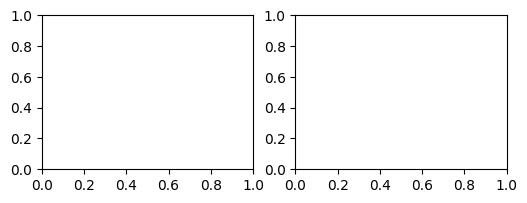

In [ ]:
# Example usage
fig, ((ax1,ax2)) = plt.subplots(1,2,figsize=(6,2)) # Create a 2x1 subgraph layout with an overall graphic size of 10x8 inches

*   `plt.tight_layout()`

  Automatically adjust the subgraph parameters to avoid label overlap.

b. Drawing method

*   `ax.plot(x,y,format_string, label)`
    Draw a line graph on the specified Axes

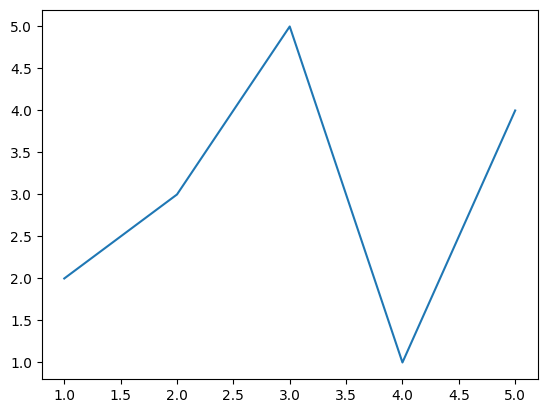

In [ ]:
# Example usage
x = [1, 2, 3, 4, 5]  # data
y = [2, 3, 5, 1, 4]

fig, ax = plt.subplots()  # Create graphics and coordinate axes
ax.plot(x, y)  # plot the line graph

c. Chart decoration

*   `ax.set_title()`, `ax.set_xlabel()`, `ax.set_ylabel()`: Set the chart title and coordinate axis labels
*   `ax.legend()`: Show the legend
*   `plt.savefig()`: Save the graphics to a file
*   `plt.show()`: Show the graph

2. Plot the figures

We want to totally draw the six figures:

 the SIR model for size1

*   the SIR model for size1

*   the SIR model for size2

*   daily new infected individuals

*   daily cummulative attack rate

*   the probability distribution changes over time

1) Create a subgraph grid with 3 rows and 2 columns

In [ ]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(15, 18))

2) SIR figure for each size

*   Normally, the susceptible population (S) decreases over time, while the
infectious population (I) initially increases, reaches a peak, and then declines. The recovered population (R) continuously increases. Eventually, all populations stabilize at constant values.
*   By plotting the SIR curves for our model, we can evaluate whether the model behaves as expected.


Here we try to draw the figure1 and 2

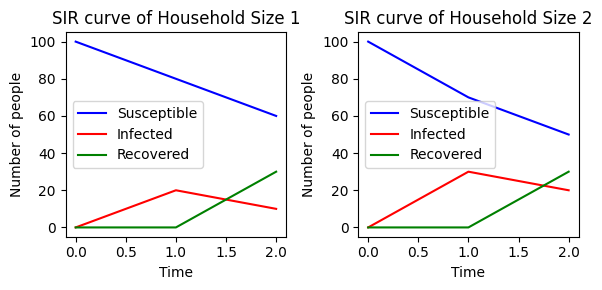

In [ ]:
# Create graphics and coordinate axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

# Sample data: The metrics_series is a list containing two family states, here we give the simple example
metrics_series = [
    [{'S': 100, 'I': 0, 'R': 0}, {'S': 80, 'I': 20, 'R': 0}, {'S': 60, 'I': 10, 'R': 30}],
    [{'S': 100, 'I': 0, 'R': 0}, {'S': 70, 'I': 30, 'R': 0}, {'S': 50, 'I': 20, 'R': 30}]
]

# Determine the length of the time series
time_length = len(metrics_series[0])  # Use the time series length of the first family
time = range(len(metrics_series[0]))  # Create a time series

# Extract the data of family size 1
size1_S = [metrics_series[0][t]['S'] for t in range(time_length)]
size1_I = [metrics_series[0][t]['I'] for t in range(time_length)]
size1_R = [metrics_series[0][t]['R'] for t in range(time_length)]

# Extract the data of family size 2
size2_S = [metrics_series[1][t]['S'] for t in range(time_length)]
size2_I = [metrics_series[1][t]['I'] for t in range(time_length)]
size2_R = [metrics_series[1][t]['R'] for t in range(time_length)]

# Draw the SIR Curve of family size 1
ax1.plot(time, size1_S, 'b-', label='Susceptible')
ax1.plot(time, size1_I, 'r-', label='Infected')
ax1.plot(time, size1_R, 'g-', label='Recovered')
ax1.set_title('SIR curve of Household Size 1')
ax1.set_xlabel('Time'), ax1.set_ylabel('Number of people'), ax1.legend()

# Draw the SIR Curve of family size 2
ax2.plot(time, size2_S, 'b-', label='Susceptible')
ax2.plot(time, size2_I, 'r-', label='Infected')
ax2.plot(time, size2_R, 'g-', label='Recovered')
ax2.set_title('SIR curve of Household Size 2')
ax2.set_xlabel('Time'), ax2.set_ylabel('Number of people'), ax2.legend()

plt.tight_layout()
plt.show()


3) daily new infected individuals

Here, we aim to determine the daily number of new cases and clearly illustrate the differences between each group.

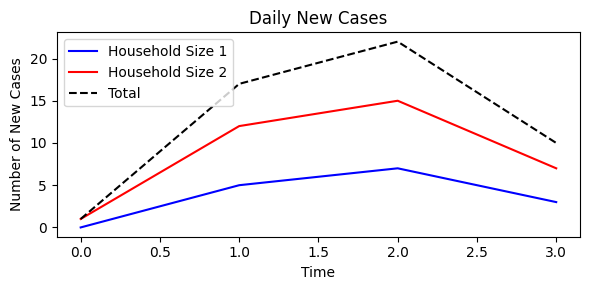

In [ ]:
# Create graphics and coordinate axes
fig, ax3 = plt.subplots(figsize=(6,3))

# Sample data
new_cases_series = [
    [0, 1],  # Time0
    [5, 12],  # Time1
    [7, 15],  # Time2
    [3, 7]    # Time3
]

# Get the time series
time_new = range(len(new_cases_series))

# Extract the data of new cases
new_cases1 = [nc[0] for nc in new_cases_series]  # New cases in the size1 family
new_cases2 = [nc[1] for nc in new_cases_series]  # New cases in the size2 family
new_cases_total = [nc1 + nc2 for nc1, nc2 in zip(new_cases1, new_cases2)] # New cases of the total population

# Draw the Curves
ax3.plot(time_new, new_cases1, 'b-', label='Household Size 1')
ax3.plot(time_new, new_cases2, 'r-', label='Household Size 2')
ax3.plot(time_new, new_cases_total, 'k--', label='Total')
ax3.set_title('Daily New Cases')
ax3.set_xlabel('Time'), ax3.set_ylabel('Number of New Cases'), ax3.legend()

plt.tight_layout()
plt.show()

4) daily cummulative attack rate

 *   The attack rate is the proportion of an at-risk population that contracts the disease during a specified time interval

\begin{aligned}
\text{attack rate} &= \frac{\text{number of new cases in the population at risk}}{\text{number of persons at risk in the population}}
\end{aligned}

*   In our case, the size1 population is 10, the size2 population is 20, and the total population is 30.

  Therefore, the attack rate for size1 is calculated as new_cases1 divided by 10, the attack rate for size2 is new_cases2 divided by 20, and the overall attack rate for the total population is (new_cases1 + new_cases2) divided by 30.

*   Here, we aim to determine the daily number of new cases and clearly illustrate the differences between each group.

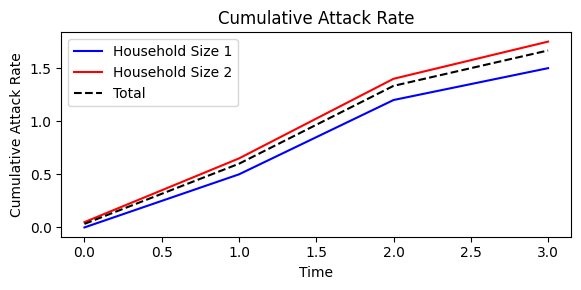

In [ ]:
# Create graphics and coordinate axes
fig, ax4 = plt.subplots(figsize=(6,3))

# Calculate the data of attack rate
cum_cases1 = np.cumsum(new_cases1)/10  # size1 cumulative attack rate
cum_cases2 = np.cumsum(new_cases2)/20  # size2 cumulative attack rate
cum_cases_total = (np.cumsum(new_cases1)+np.cumsum(new_cases2))/30  # total attack rate

# Draw the Curves
ax4.plot(time_new, cum_cases1, 'b-', label='Household Size 1')
ax4.plot(time_new, cum_cases2, 'r-', label='Household Size 2')
ax4.plot(time_new, cum_cases_total, 'k--', label='Total')
ax4.set_title('Cumulative Attack Rate')
ax4.set_xlabel('Time'), ax4.set_ylabel('Cumulative Attack Rate'), ax4.legend()

plt.tight_layout()
plt.show()

5) the probability distribution changes over time

Recall that we have 9 possible states: (1,0,0,1), (0,1,0,1), (0,0,1,1), (2,0,0,2), (0,2,0,2), (0,0,2,2), (1,1,0,2), (1,0,1,2), (0,1,1,2)

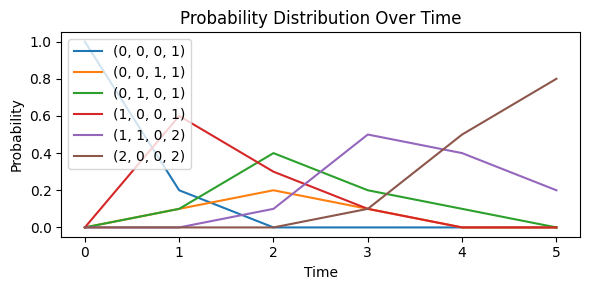

In [ ]:
# Create graphics and coordinate axes
fig, ax5 = plt.subplots(figsize=(6,3))

# Sample data: Each distribution is a dictionary containing the probabilities of each state, here we use a simple example to simulate the possible process
distributions = [
    {   (0,0,0,1): 1.0, (1,0,0,1): 0.0, (0,1,0,1): 0.0, (0,0,1,1): 0.0, (1,1,0,2): 0.0, (2,0,0,2): 0.0 # Time0
    },
    {   (0,0,0,1): 0.2, (1,0,0,1): 0.6, (0,1,0,1): 0.1, (0,0,1,1): 0.1, (1,1,0,2): 0.0, (2,0,0,2): 0.0 # Time1
    },
    {   (0,0,0,1): 0.0, (1,0,0,1): 0.3, (0,1,0,1): 0.4, (0,0,1,1): 0.2, (1,1,0,2): 0.1, (2,0,0,2): 0.0 # Time2
    },
    {   (0,0,0,1): 0.0, (1,0,0,1): 0.1, (0,1,0,1): 0.2, (0,0,1,1): 0.1, (1,1,0,2): 0.5, (2,0,0,2): 0.1 # Time3
    },
    {   (0,0,0,1): 0.0, (1,0,0,1): 0.0, (0,1,0,1): 0.1, (0,0,1,1): 0.0, (1,1,0,2): 0.4, (2,0,0,2): 0.5 # Time4
    },
    {   (0,0,0,1): 0.0, (1,0,0,1): 0.0, (0,1,0,1): 0.0, (0,0,1,1): 0.0, (1,1,0,2): 0.2, (2,0,0,2): 0.8 # Time5
    }
]

# Obtain all possible states
all_states = sorted(distributions[0].keys())
time = range(len(distributions))

# Draw a curve for each state
for state in all_states:
    probabilities = [dist[state] for dist in distributions]
    ax5.plot(time, probabilities, label=f'{state}')

ax5.set_title('Probability Distribution Over Time')
ax5.set_xlabel('Time'), ax5.set_ylabel('Probability'), ax5.legend()

plt.tight_layout()
plt.show()

3. Summary

Now we can combine the five figures to one method.

In [ ]:
def plot_results(metrics_series, new_cases_series):
    """Draw the result chart"""
    fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(15, 18))

    # size1 The probability distribution curve of each state
    time = range(len(metrics_series))
    size1_S = [m[0]['S'] for m in metrics_series]
    size1_I = [m[0]['I'] for m in metrics_series]
    size1_R = [m[0]['R'] for m in metrics_series]

    ax1.plot(time, size1_S, 'b-', label='Susceptible')
    ax1.plot(time, size1_I, 'r-', label='Infected')
    ax1.plot(time, size1_R, 'g-', label='Recovered')
    ax1.set_title('SIR curve of Household Size 1')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Number of people')
    ax1.legend()

    # size2 The probability distribution curve of each state
    size2_S = [m[1]['S'] for m in metrics_series]
    size2_I = [m[1]['I'] for m in metrics_series]
    size2_R = [m[1]['R'] for m in metrics_series]

    ax2.plot(time, size2_S, 'b-', label='Susceptible')
    ax2.plot(time, size2_I, 'r-', label='Infected')
    ax2.plot(time, size2_R, 'g-', label='Recovered')
    ax2.set_title('SIR curve of Household Size 2')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Number of people')
    ax2.legend()

    # Daily new cases
    time_new = range(len(new_cases_series))
    new_cases1 = [nc[0] for nc in new_cases_series]
    new_cases2 = [nc[1] for nc in new_cases_series]
    new_cases_total = [nc1 + nc2 for nc1, nc2 in zip(new_cases1, new_cases2)]

    ax3.plot(time_new, new_cases1, 'b-', label='Household Size 1')
    ax3.plot(time_new, new_cases2, 'r-', label='Household Size 2')
    ax3.plot(time_new, new_cases_total, 'k--', label='Total')
    ax3.set_title('Daily New Cases')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('Number of New Cases')
    ax3.legend()

    # Daily cumulative cases
    cum_cases1 = np.cumsum(new_cases1)/10
    cum_cases2 = np.cumsum(new_cases2)/20
    cum_cases_total = (np.cumsum(new_cases1)+np.cumsum(new_cases2))/30

    ax4.plot(time_new, cum_cases1, 'b-', label='Household Size 1')
    ax4.plot(time_new, cum_cases2, 'r-', label='Household Size 2')
    ax4.plot(time_new, cum_cases_total, 'k--', label='Total')
    ax4.set_title('Cumulative Attack Rate')
    ax4.set_xlabel('Time')
    ax4.set_ylabel('Cumulative Attack Rate')
    ax4.legend()

    all_states = sorted(distributions[0].keys())
    time = range(len(distributions))

    for state in all_states:
        probabilities = [dist[state] for dist in distributions]
        ax5.plot(time, probabilities, label=f'State {state}')

    # Probability distribution graphs at different times
    ax5.set_title('Probability Distribution Over Time')
    ax5.set_xlabel('Time')
    ax5.set_ylabel('Probability')
    ax5.legend()

    plt.tight_layout()
    plt.savefig("my_plot.png")
    plt.show()


**Step 6**. Data Export

*   To ensure more accurate data analysis, we can create a probability chart in Excel that displays precise figures at each time point. The Excel chart should include the following columns:
  *   Probability at each state
  *   Expected current infected
  *   Expected daily new infections
  *   Expected cumulative attack rate


*   We need:

  *   distributions (list of dict): A list where each entry is a dictionary representing the probability distribution of states at each time step. Each key in the dictionary is a state label.
  *   new_cases_series (list of tuples): A list where each entry is a tuple (new_cases1, new_cases2) representing the expected number of new infections at each timestep.

*   We will return: A pandas DataFrame containing the detailed table with probabilities for each state,expected current infected, expected daily new infected, and expected cumulative attack rate for each time step.


In [ ]:
def create_detailed_distribution_table(distributions, new_cases_series):
    """Create an Excel probability distribution probability table"""
    # Collect all possible states
    all_states = sorted(distributions[0].keys())
    # Prepare a list to store table rows (each row is a dict mapping column name to value)
    data = []

    # Construct column names for the table.
    # Start with 'Time', followed by one column for each state's probability, and then summary metrics.
    columns = ['Time']
    for state in all_states:
        columns.append(f'P{state}')  # Probability column for each state, e.g., P(1,0,0,1)
    columns.extend([
        'Expected Current Infected',
        'Expected Daily New Infected',
        'Expected Cumulative Attack Rate'
    ])

    # Initialize the cumulative infected counter
    cumulative_infected = 0
    # Loop over each time step to fill in the data
    for t, dist in enumerate(distributions):
        # Create a new row for the table, starting with the current time step
        row = {'Time': t}
        # Add the probability for each state at this time step
        for state in all_states:
            row[f'P{state}'] = dist[state]

        # Compute expected number of currently infected individuals at this step
        # Assume get_total_S_I is a helper function returning (S_total, I_total) expectations
        S_tot, I_tot = get_total_S_I(dist)
        row['Expected Current Infected'] = I_tot

        # Compute expected number of new infections for this time step
        if t == 0:
            expected_daily_new_infected = 0  # For the very first timestep, there are no new infections yet
        else:
            # For subsequent steps, use new_cases_series to get new infected counts
            if t - 1 < len(new_cases_series):
                # Get expected new cases from the series
                new_cases1, new_cases2 = new_cases_series[t - 1]
                expected_daily_new_infected = new_cases1 + new_cases2
            else:
                expected_daily_new_infected = float('nan')  # If we've run out of new_cases_series data, mark as NaN (not a number)
        row['Expected Daily New Infected'] = expected_daily_new_infected

        # Update the cumulative number of infected by adding today's new infections
        cumulative_infected += expected_daily_new_infected
        # Compute the expected cumulative attack rate as the fraction of the population infected
        expected_cumulative_attack_rate = cumulative_infected / N
        row['Expected Cumulative Attack Rate'] = expected_cumulative_attack_rate

        # Append the completed row to the data list
        data.append(row)

    # Convert the list of row dictionaries into a pandas DataFrame with the specified column order
    df = pd.DataFrame(data, columns=columns)
    return df



**Step 7.** Run Simulation and Display Results

With all the necessary functions implemented, we are now able to run our model simulation and obtain the results.

In [ ]:
# Run simulation
time_steps = 100
distributions, metrics_series, new_cases_series = run_simulation(dist_0, time_steps)

# Create and save distribution table
df = create_detailed_distribution_table(distributions, metrics_series, new_cases_series)

# Save DataFrame to Excel file
df.to_excel('epidemic_distribution.xlsx', index=False)

# Plot results
plot_results(metrics_series, new_cases_series)

**Step 8**: Summary

The whole code looks like this

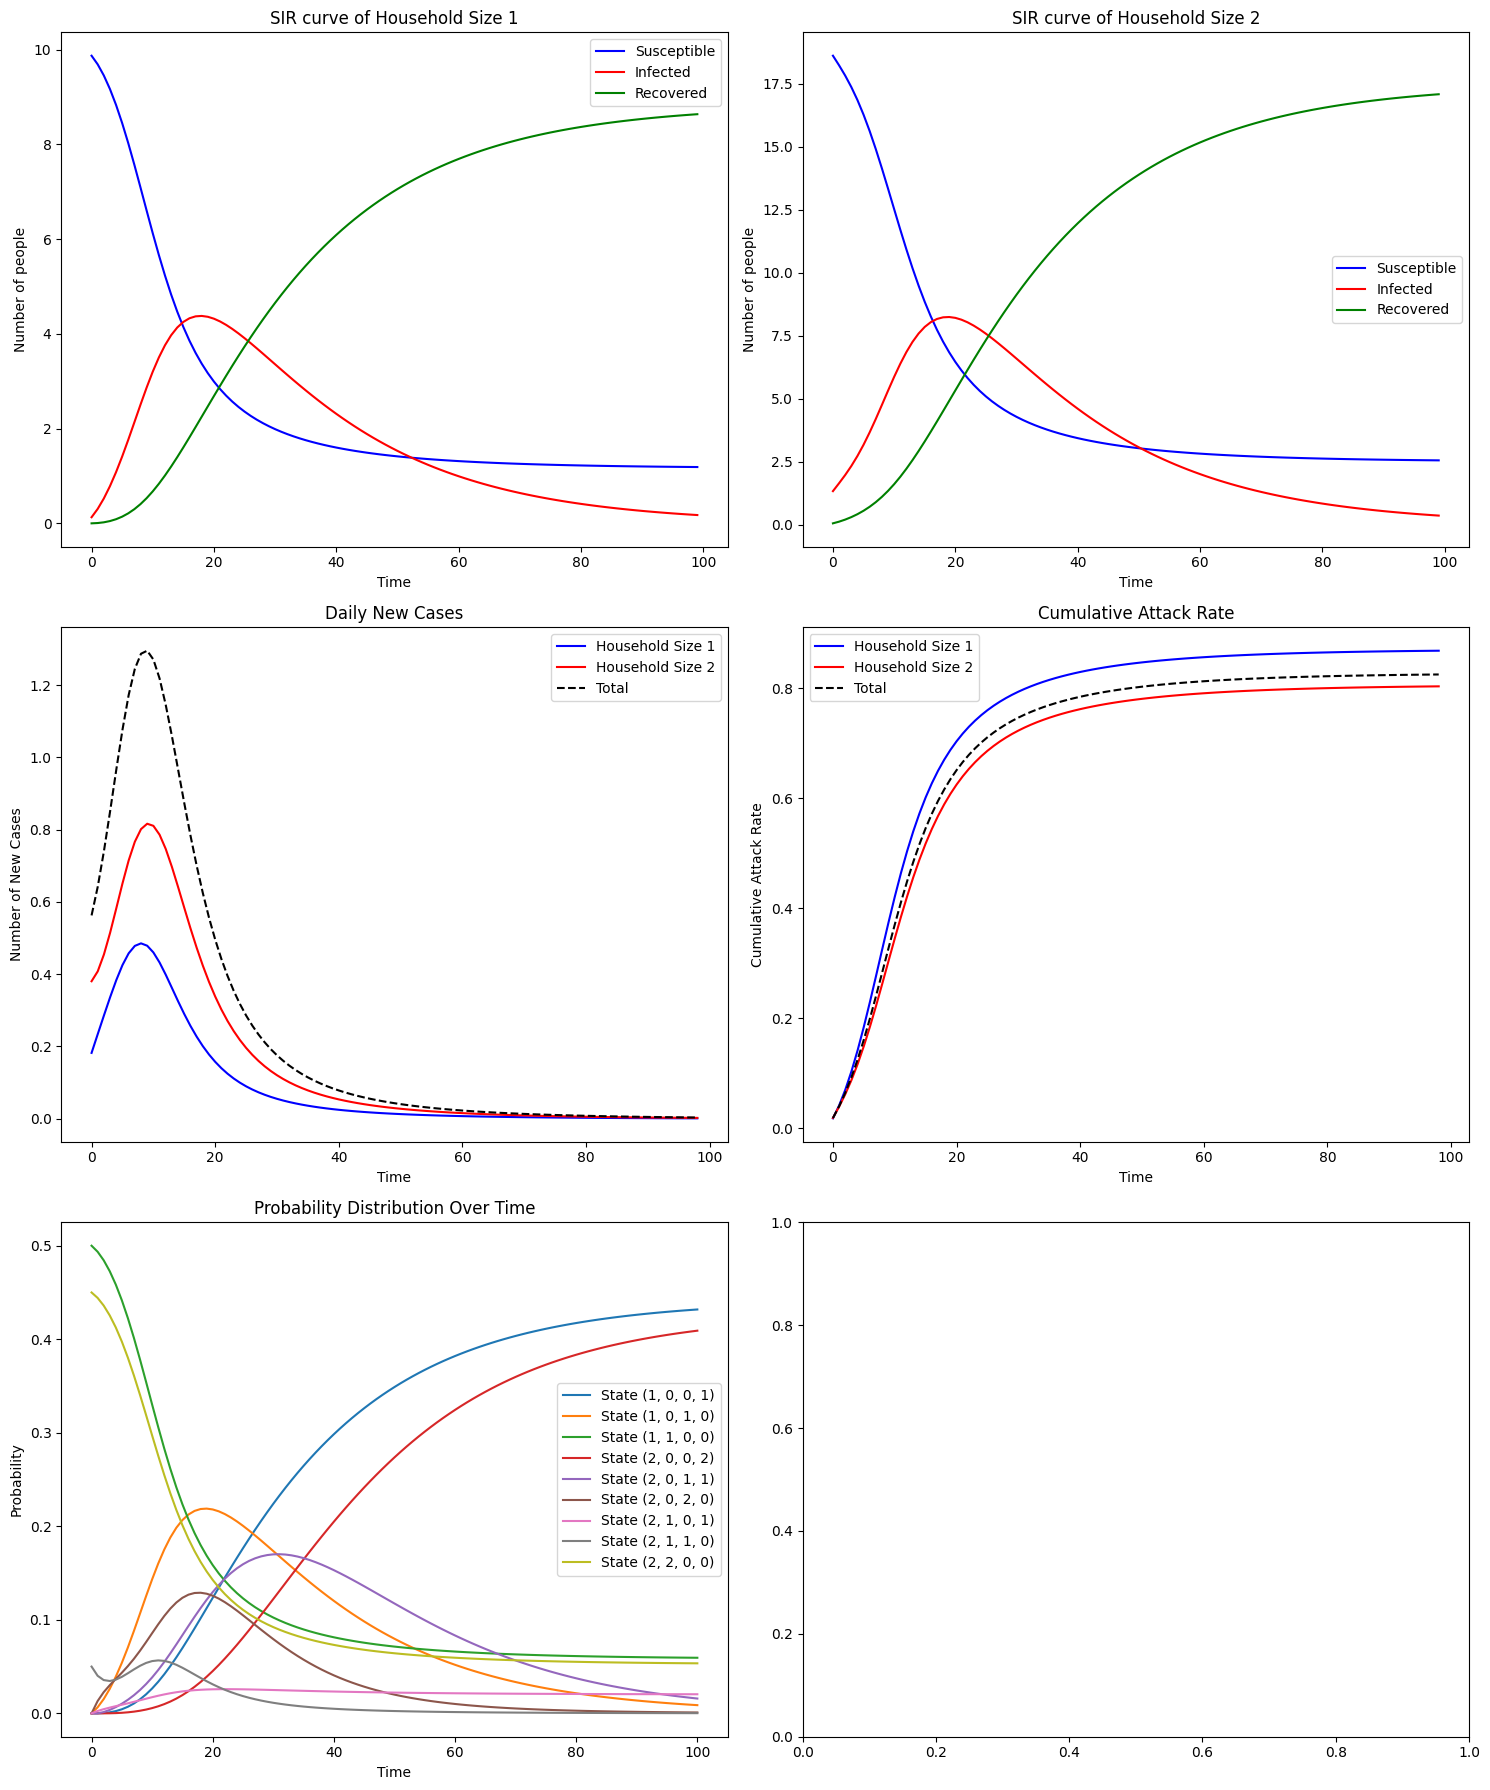

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
from openpyxl.workbook import Workbook

# Parameter settings
N = 30  # Total population
K = 20  # Total number of households
beta_c = 0.4  # Inter-household transmission coefficient
beta_h = 1  # Intra-household transmission coefficient
alpha = 0.05  # Recovery rate

def get_total_S_I(dist):
    """Calculate the total S and I"""
    S = I = 0
    for (n, s, i, r), p in dist.items():  # dist: state distribution dictionary. Key: household state (n, s, i, r). Value: probability.
        S += s * p * K  # The number of susceptible individuals per household * the probability of that state * the number of households in that state = contribution of that state to susceptible individuals
        I += i * p * K
    return S, I

def get_infection_prob(s, i, n, S_tot, I_tot):
    """Calculate infection probability"""
    if s == 0:
        return 0  # If there are no infected individuals, the infection probability is 0
    p_comm = beta_c * S_tot * I_tot / (N * N)  # Calculate inter-household transmission probability
    p_house = beta_h * s * i / (n * n) if i > 0 else 0  # Calculate intra-household transmission probability
    return p_comm + p_house

def get_recovery_prob(i):
    """Calculate recovery probability"""
    return alpha * i if i > 0 else 0

def find_possible_previous_states(current_state):
    """Find all possible previous states that could transition to the current state through infection or recovery"""
    n, s, i, r = current_state  # Assign variables
    possible_states = []  # Create a list to store all possible previous states

    # If the current state has recoveries (r > 0), it means it could have transitioned from an infected individual recovering
    if r > 0:
        prev_recover = (n, s, i + 1, r - 1)
        possible_states.append((prev_recover, 'recover'))

    # If the current state has infected individuals (i > 0), it means it could have transitioned from a susceptible individual getting infected
    if i > 0:
        prev_infect = (n, s + 1, i - 1, r)
        possible_states.append((prev_infect, 'infect'))

    return possible_states

def one_step_update(dist_current):
    """Use backtracking to compute the distribution at the next time step"""
    # Calculate the total S and I
    S_tot, I_tot = get_total_S_I(dist_current)

    # All possible states
    all_states = list(dist_current.keys())
    dist_next = {state: 0.0 for state in all_states}  # Store the probability for each state at the next time step

    for current_state in all_states:
        # Current state's staying probability
        n, s, i, r = current_state
        p_infect = get_infection_prob(s, i, n, S_tot, I_tot)
        p_recover = get_recovery_prob(i)
        p_stay = 1 - p_infect - p_recover

        # Add the staying probability contribution
        if current_state in dist_current:
            dist_next[current_state] += dist_current[current_state] * p_stay  # Stay in the same state

        # Find all possible previous states
        possible_prev_states = find_possible_previous_states(current_state)

        # Check if these states exist in the current distribution and calculate transition probabilities
        for prev_state, trans_type in possible_prev_states:
            if prev_state in dist_current and dist_current[prev_state] > 0:
                if trans_type == 'recover':
                    p_trans = get_recovery_prob(prev_state[2])  # i of prev_state
                else:  # infect
                    p_trans = get_infection_prob(prev_state[1], prev_state[2], prev_state[0], S_tot, I_tot)

                dist_next[current_state] += dist_current[prev_state] * p_trans  # Transition from other states

    return dist_next

# Initial distribution
dist_0 = {
    (1, 1, 0, 0): 10 / K,  # 10 single-person susceptible households
    (2, 2, 0, 0): 9 / K,  # 9 double-person susceptible households
    (2, 1, 1, 0): 1 / K  # 1 mixed double-person household
}

# All possible states
all_states = [(n, s, i, n - s - i) for n in [1, 2]
    for s in range(n + 1) for i in range(n + 1 - s)]

# Fill other possible states' probabilities to 0
for state in all_states:
    dist_0.setdefault(state, 0.0)

def calculate_metrics(dist):
    """Calculate key metrics at the current time point"""
    size1_metrics = {'S': 0, 'I': 0, 'R': 0, 'total': 0}
    size2_metrics = {'S': 0, 'I': 0, 'R': 0, 'total': 0}

    for (n, s, i, r), p in dist.items():
        if n == 1:
            size1_metrics['S'] += s * p * K
            size1_metrics['I'] += i * p * K
            size1_metrics['R'] += r * p * K
            size1_metrics['total'] += n * p * K
        elif n == 2:
            size2_metrics['S'] += s * p * K
            size2_metrics['I'] += i * p * K
            size2_metrics['R'] += r * p * K
            size2_metrics['total'] += n * p * K

    return size1_metrics, size2_metrics

def calculate_new_cases(prev_dist, curr_dist):
    """Calculate daily new cases"""
    # Calculate total infected and recovered for each household type
    prev_size1, prev_size2 = calculate_metrics(prev_dist)
    curr_size1, curr_size2 = calculate_metrics(curr_dist)

    # Ensure initial new cases are 0
    new_cases1 = 0
    new_cases2 = 0

    # Calculate new cases for household types 1 and 2
    if prev_size1 and prev_size2:
        new_cases1 = max(0, (curr_size1['I'] + curr_size1['R']) -
                         (prev_size1['I'] + prev_size1['R']))
        new_cases2 = max(0, (curr_size2['I'] + curr_size2['R']) -
                         (prev_size2['I'] + prev_size2['R']))

    return new_cases1, new_cases2

def run_simulation(initial_dist, time_steps):
    """Run simulation and record data"""
    distributions = [initial_dist]  # Probability distribution for each time step
    metrics_series = []  # Metrics for each time step
    new_cases_series = []  # New cases for each time step
    current_dist = initial_dist

    for t in range(time_steps):
        next_dist = one_step_update(current_dist)  # Calculate transition from current state to next state
        distributions.append(next_dist)

        size1_metrics, size2_metrics = calculate_metrics(next_dist)
        metrics_series.append((size1_metrics, size2_metrics))

        if t > 0:
            new_cases = calculate_new_cases(current_dist, next_dist)
            new_cases_series.append(new_cases)

        current_dist = next_dist  # Use next state for the next time step

    return distributions, metrics_series, new_cases_series

def plot_results(metrics_series, new_cases_series):
    """Plot result charts"""
    fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(15, 16))

    # size1 probability distribution curves
    time = range(len(metrics_series))
    size1_S = [m[0]['S'] for m in metrics_series]
    size1_I = [m[0]['I'] for m in metrics_series]
    size1_R = [m[0]['R'] for m in metrics_series]

    ax1.plot(time, size1_S, 'b-', label='Susceptible')
    ax1.plot(time, size1_I, 'r-', label='Infected')
    ax1.plot(time, size1_R, 'g-', label='Recovered')
    ax1.set_title('SIR curve of Household Size 1')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Number of people')
    ax1.legend()

    # size2 probability distribution curves
    size2_S = [m[1]['S'] for m in metrics_series]
    size2_I = [m[1]['I'] for m in metrics_series]
    size2_R = [m[1]['R'] for m in metrics_series]

    ax2.plot(time, size2_S, 'b-', label='Susceptible')
    ax2.plot(time, size2_I, 'r-', label='Infected')
    ax2.plot(time, size2_R, 'g-', label='Recovered')
    ax2.set_title('SIR curve of Household Size 2')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Number of people')
    ax2.legend()

    # Daily new cases
    time_new = range(len(new_cases_series))
    new_cases1 = [nc[0] for nc in new_cases_series]
    new_cases2 = [nc[1] for nc in new_cases_series]
    new_cases_total = [nc1 + nc2 for nc1, nc2 in zip(new_cases1, new_cases2)]

    ax3.plot(time_new, new_cases1, 'b-', label='Household Size 1')
    ax3.plot(time_new, new_cases2, 'r-', label='Household Size 2')
    ax3.plot(time_new, new_cases_total, 'k--', label='Total')
    ax3.set_title('Daily New Cases')
    ax3.set_xlabel('Time')
    ax3.set_ylabel('Number of New Cases')
    ax3.legend()

    # Cumulative cases
    cum_cases1 = np.cumsum(new_cases1) / 10
    cum_cases2 = np.cumsum(new_cases2) / 20
    cum_cases_total = (np.cumsum(new_cases1) + np.cumsum(new_cases2)) / 30

    ax4.plot(time_new, cum_cases1, 'b-', label='Household Size 1')
    ax4.plot(time_new, cum_cases2, 'r-', label='Household Size 2')
    ax4.plot(time_new, cum_cases_total, 'k--', label='Total')
    ax4.set_title('Cumulative Attack Rate')
    ax4.set_xlabel('Time')
    ax4.set_ylabel('Cumulative Attack Rate')
    ax4.legend()

    all_states = sorted(distributions[0].keys())
    time = range(len(distributions))

    for state in all_states:
        probabilities = [dist[state] for dist in distributions]
        ax5.plot(time, probabilities, label=f'State {state}')

    # Probability distribution over time
    ax5.set_title('Probability Distribution Over Time')
    ax5.set_xlabel('Time')
    ax5.set_ylabel('Probability')
    ax5.legend()

    plt.tight_layout()
    plt.savefig("my_plot.png")
    plt.show()

def create_detailed_distribution_table(distributions, new_cases_series):
    """Create Excel probability distribution table"""
    all_states = sorted(distributions[0].keys())
    data = []

    # Create column names
    columns = ['Time']
    for state in all_states:
        columns.append(f'P{state}')  # Add probability column
    columns.extend([
        'Expected Current Infected',  # Expected number of current infected individuals
        'Expected Daily New Infected',  # Expected number of daily new infected individuals
        'Expected Cumulative Attack Rate'  # Expected value of cumulative attack rate
    ])

    # Initialize cumulative infected count
    cumulative_infected = 0
    # Fill data
    for t, dist in enumerate(distributions):
        row = {'Time': t}
        for state in all_states:
            row[f'P{state}'] = dist[state]
            # Calculate expected number of current infected individuals
        S_tot, I_tot = get_total_S_I(dist)
        row['Expected Current Infected'] = I_tot

        # Calculate expected number of daily new infected individuals
        if t == 0:
            expected_daily_new_infected = 0  # No new infected individuals at the initial time step
        else:
            # Ensure it does not exceed the range of new_cases_series
            if t - 1 < len(new_cases_series):
                new_cases1, new_cases2 = new_cases_series[t - 1]
                expected_daily_new_infected = new_cases1 + new_cases2
            else:
                expected_daily_new_infected = float('nan')  # Set to NaN if out of range
        row['Expected Daily New Infected'] = expected_daily_new_infected

        # Calculate expected value of cumulative attack rate
        cumulative_infected += expected_daily_new_infected
        expected_cumulative_attack_rate = cumulative_infected / N
        row['Expected Cumulative Attack Rate'] = expected_cumulative_attack_rate

        data.append(row)

    df = pd.DataFrame(data, columns=columns)
    return df

# Run the simulation
time_steps = 100
distributions, metrics_series, new_cases_series = run_simulation(dist_0, time_steps)

# Create and save the distribution table
df = create_detailed_distribution_table(distributions, new_cases_series)

# Save the DataFrame as an Excel file
df.to_excel('epidemic_distribution.xlsx', index=False)

# Plot the results
plot_results(metrics_series, new_cases_series)

**5. Extension: Object-Oriented Implementation for Epidemic Modeling**

When implementing this epidemic simulation program in practice, we can adopt an object-oriented approach to create a more robust and user-friendly tool. As you'll discover through this implementation, structuring the code using classes and objects makes the simulation more intuitive to use while maintaining all the analytical capabilities.

To run a simulation, users simply need to provide several key parameters:  the between-household transmission coefficient (βc) representing how easily infections spread between different families, the within-household transmission coefficient (βh) showing transmission risk among family members, the recovery rate (α) indicating how quickly individuals recover, the household size distribution specifying how many households exist of each size, and finally the desired number of time steps for the simulation duration.

The program then generates comprehensive outputs for analysis, beginning with a detailed Excel spreadsheet that records the probability distributions of all possible disease states at each time point throughout the simulation.  Additionally, it can produce some valuable visualizations.

Here's the core implementation:

Please enter simulation parameters:
Between-household transmission coefficient (default 0.4): 0.4
Within-household transmission coefficient (default 0.4): 0.4
Recovery rate (default 0.1): 0.1

Enter counts for each household size (enter 0 to finish):
Household size (number of people, enter 0 to finish): 2
Number of 2-person households: 30
Household size (number of people, enter 0 to finish): 3
Number of 3-person households: 30
Household size (number of people, enter 0 to finish): 0

Simulation time steps (default 200): 100

Running simulation...
Results saved to epidemic_distribution.xlsx
Generating plots...


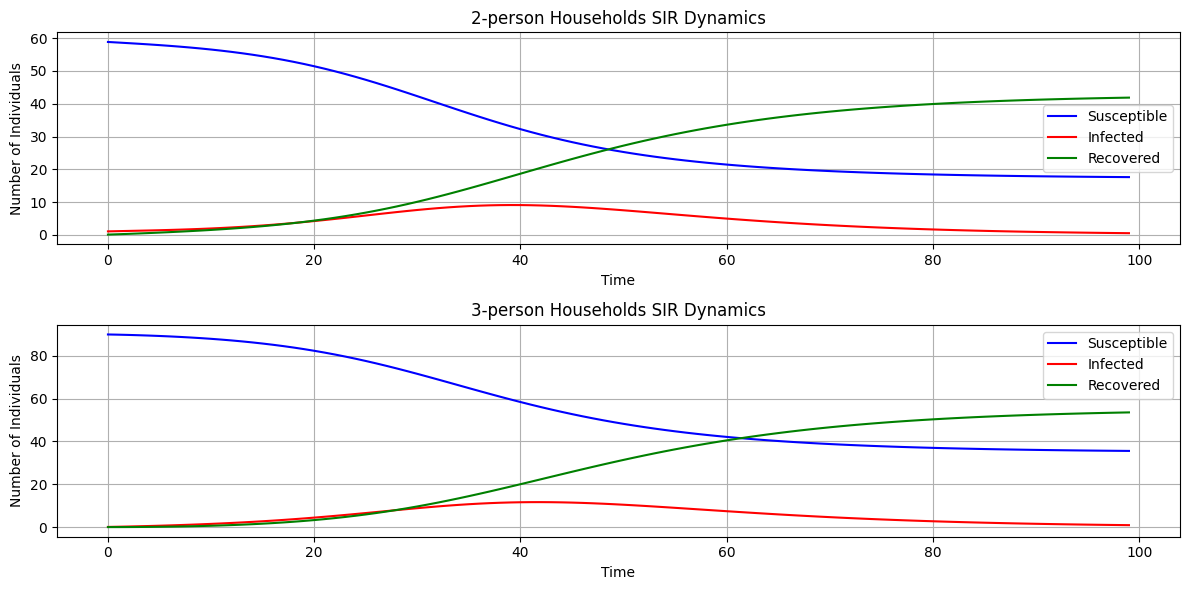

/tmp/ipython-input-1-1790593414.py:327: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


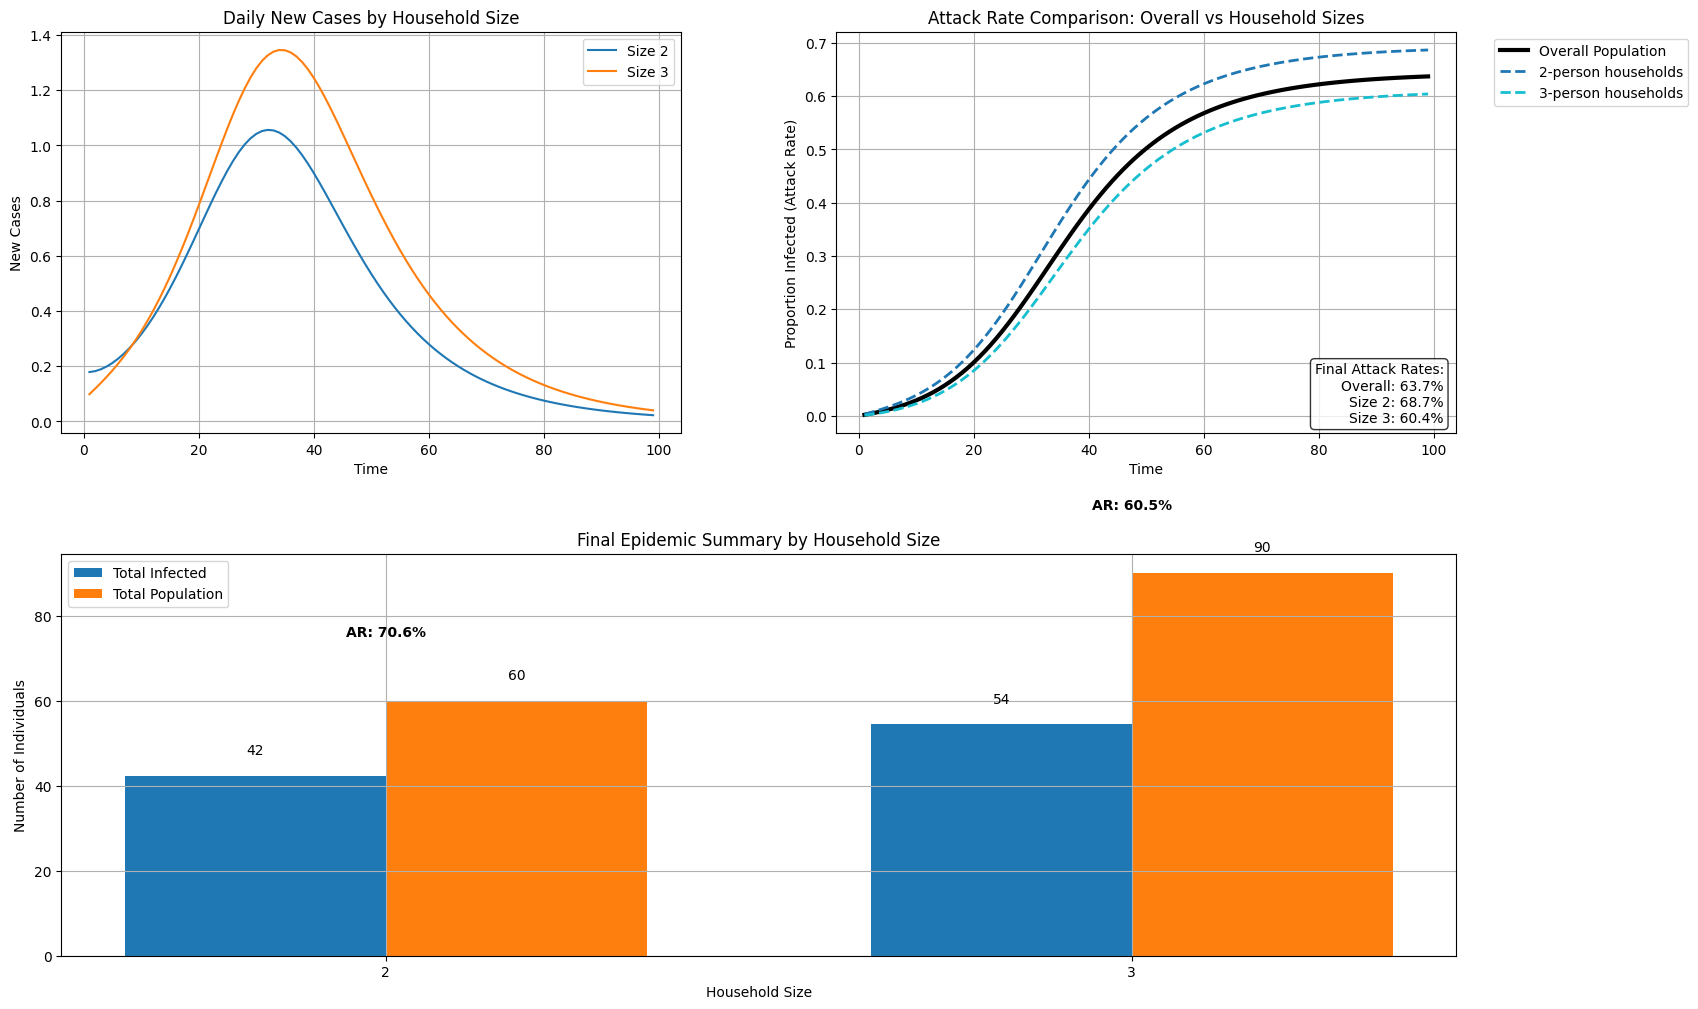

Household SIR dynamics plot saved to household_sir_dynamics.png
Epidemic analysis plot saved to epidemic_analysis.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict


class HouseholdEpidemicSimulation:
    def __init__(self, beta_c=0.4, beta_h=0.4, alpha=0.1, household_counts=None):
        """
        Initialize the simulator

        Parameters:
        - beta_c: between-household transmission coefficient
        - beta_h: within-household transmission coefficient
        - alpha: recovery rate
        - household_counts: dictionary where keys are household sizes and values are counts of such households
        """
        if household_counts is None:
            household_counts = {2: 39, 3: 47, 4: 69, 5: 45, 6: 16}

        self.beta_c = beta_c
        self.beta_h = beta_h
        self.alpha = alpha
        self.household_counts = household_counts

        # Calculate total households and total population
        self.K = sum(household_counts.values())
        self.N = sum(size * count for size, count in household_counts.items())
        self.household_sizes = sorted(household_counts.keys())

        # Initialize distribution
        self.initial_dist = self._initialize_distribution()

    def _initialize_distribution(self):
        """Initialize the household state distribution"""
        dist = defaultdict(float)

        # Set initial state: all households are fully susceptible
        for n, count in self.household_counts.items():
            dist[(n, n, 0, 0)] = count / self.K

        # Randomly select one household and convert one person from susceptible (S) to infected (I)
        household_sizes = list(self.household_counts.keys())
        weights = list(self.household_counts.values())
        chosen_size = np.random.choice(household_sizes, p=np.array(weights) / self.K)

        # Update initial distribution
        dist[(chosen_size, chosen_size, 0, 0)] -= 1 / self.K
        dist[(chosen_size, chosen_size - 1, 1, 0)] += 1 / self.K

        # Fill other possible states with probability 0
        for n in self.household_counts.keys():
            for s in range(n + 1):
                for i in range(n + 1 - s):
                    r = n - s - i
                    dist.setdefault((n, s, i, r), 0.0)

        return dist

    def get_total_S_I(self, dist):
        """Calculate total susceptible and infected individuals"""
        S = I = 0
        for (n, s, i, r), p in dist.items():
            S += s * p * self.K
            I += i * p * self.K
        return S, I

    def get_infection_prob(self, s, i, n, S_tot, I_tot):
        """Calculate infection probability"""
        if s == 0:
            return 0
        p_comm = self.beta_c * S_tot * I_tot / (self.N * self.N)
        p_house = self.beta_h * s * i / (n * n) if i > 0 else 0
        return p_comm + p_house

    def get_recovery_prob(self, i):
        """Calculate recovery probability"""
        return self.alpha * i if i > 0 else 0

    def find_possible_previous_states(self, current_state):
        """Find possible previous states that could lead to current state"""
        n, s, i, r = current_state
        possible_states = []

        if r > 0:
            prev_recover = (n, s, i + 1, r - 1)
            possible_states.append((prev_recover, 'recover'))

        if i > 0:
            prev_infect = (n, s + 1, i - 1, r)
            possible_states.append((prev_infect, 'infect'))

        return possible_states

    def one_step_update(self, dist_current):
        """Perform one time step update of state distribution"""
        S_tot, I_tot = self.get_total_S_I(dist_current)
        all_states = list(dist_current.keys())
        dist_next = {state: 0.0 for state in all_states}

        for current_state in all_states:
            n, s, i, r = current_state
            p_infect = self.get_infection_prob(s, i, n, S_tot, I_tot)
            p_recover = self.get_recovery_prob(i)
            p_stay = 1 - p_infect - p_recover

            dist_next[current_state] += dist_current[current_state] * p_stay

            possible_prev_states = self.find_possible_previous_states(current_state)

            for prev_state, trans_type in possible_prev_states:
                if prev_state in dist_current and dist_current[prev_state] > 0:
                    if trans_type == 'recover':
                        p_trans = self.get_recovery_prob(prev_state[2])
                    else:
                        p_trans = self.get_infection_prob(prev_state[1], prev_state[2], prev_state[0], S_tot, I_tot)

                    dist_next[current_state] += dist_current[prev_state] * p_trans

        return dist_next

    def calculate_metrics(self, dist):
        """Calculate SIR metrics for each household size"""
        metrics = {n: {'S': 0, 'I': 0, 'R': 0, 'total': 0}
                   for n in self.household_counts.keys()}

        for (n, s, i, r), p in dist.items():
            if n in metrics:
                metrics[n]['S'] += s * p * self.K
                metrics[n]['I'] += i * p * self.K
                metrics[n]['R'] += r * p * self.K
                metrics[n]['total'] += n * p * self.K

        return metrics

    def calculate_new_cases(self, prev_dist, curr_dist):
        """Calculate new cases between two time steps"""
        prev_metrics = self.calculate_metrics(prev_dist)
        curr_metrics = self.calculate_metrics(curr_dist)

        new_cases = {}
        for n in self.household_counts.keys():
            prev_infected = prev_metrics[n]['I'] + prev_metrics[n]['R']
            curr_infected = curr_metrics[n]['I'] + curr_metrics[n]['R']
            new_cases[n] = max(0, curr_infected - prev_infected)

        return new_cases

    def run_simulation(self, time_steps=200):
        """Run the simulation for given number of time steps"""
        self.distributions = [self.initial_dist]
        self.metrics_series = []
        self.new_cases_series = []
        current_dist = self.initial_dist

        for t in range(time_steps):
            next_dist = self.one_step_update(current_dist)
            self.distributions.append(next_dist)

            metrics = self.calculate_metrics(next_dist)
            self.metrics_series.append(metrics)

            if t > 0:
                new_cases = self.calculate_new_cases(current_dist, next_dist)
                self.new_cases_series.append(new_cases)

            current_dist = next_dist

        return self.distributions, self.metrics_series, self.new_cases_series

    def create_detailed_distribution_table(self):
        """Create detailed distribution table for all time steps"""
        all_states = sorted(self.distributions[0].keys())
        data = []

        columns = ['Time'] + [f'P{state}' for state in all_states] + [
            'Total_S', 'Total_I', 'Total_R',
            *[f'Size{n}_I' for n in self.household_counts.keys()],
            'Daily_New_Cases',
            'Cumulative_Attack_Rate'
        ]

        cumulative_cases = 0

        for t, dist in enumerate(self.distributions):
            row = {'Time': t}

            for state in all_states:
                row[f'P{state}'] = dist[state]

            S_tot, I_tot = self.get_total_S_I(dist)
            R_tot = self.N - S_tot - I_tot
            row.update({
                'Total_S': S_tot,
                'Total_I': I_tot,
                'Total_R': R_tot
            })

            metrics = self.calculate_metrics(dist)
            for n in self.household_counts.keys():
                row[f'Size{n}_I'] = metrics[n]['I']

            if t == 0:
                row['Daily_New_Cases'] = 0
            else:
                if t - 1 < len(self.new_cases_series):
                    new_cases = sum(self.new_cases_series[t - 1].values())
                else:
                    new_cases = 0
                row['Daily_New_Cases'] = new_cases
                cumulative_cases += new_cases

            row['Cumulative_Attack_Rate'] = cumulative_cases / self.N
            data.append(row)

        return pd.DataFrame(data, columns=columns)

    def plot_household_sir(self):
        """Plot SIR dynamics for each household size"""
        num_sizes = len(self.household_sizes)
        fig, axes = plt.subplots(num_sizes, 1, figsize=(12, 3 * num_sizes))

        if num_sizes == 1:
            axes = [axes]

        for idx, (size, ax) in enumerate(zip(self.household_sizes, axes)):
            time = range(len(self.metrics_series))
            S = [m[size]['S'] for m in self.metrics_series]
            I = [m[size]['I'] for m in self.metrics_series]
            R = [m[size]['R'] for m in self.metrics_series]

            ax.plot(time, S, 'b-', label='Susceptible')
            ax.plot(time, I, 'r-', label='Infected')
            ax.plot(time, R, 'g-', label='Recovered')
            ax.set_title(f'{size}-person Households SIR Dynamics')
            ax.set_xlabel('Time')
            ax.set_ylabel('Number of Individuals')
            ax.legend()
            ax.grid(True)

        plt.tight_layout()
        plt.savefig("household_sir_dynamics.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_analysis_results(self):
        """Plot analysis results (new cases, attack rates, etc.)"""
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

        # New cases plot
        ax1 = fig.add_subplot(gs[0, 0])
        time = range(1, len(self.new_cases_series) + 1)
        for size in self.household_sizes:
            cases = [nc.get(size, 0) for nc in self.new_cases_series]
            ax1.plot(time, cases, label=f'Size {size}')
        ax1.set_title('Daily New Cases by Household Size')
        ax1.set_xlabel('Time')
        ax1.set_ylabel('New Cases')
        ax1.legend()
        ax1.grid(True)

        # Attack rate comparison plot
        ax2 = fig.add_subplot(gs[0, 1])
        time = range(1, len(self.new_cases_series) + 1)

        # Calculate overall attack rate
        total_cases = [sum(nc.values()) for nc in self.new_cases_series]
        cumulative_rate = np.cumsum(total_cases) / self.N
        ax2.plot(time, cumulative_rate, 'k-', linewidth=3, label='Overall Population')

        # Plot attack rates by household size
        colors = plt.cm.tab10(np.linspace(0, 1, len(self.household_sizes)))
        for size, color in zip(self.household_sizes, colors):
            size_cases = np.cumsum([nc.get(size, 0) for nc in self.new_cases_series])
            size_attack_rate = size_cases / (size * self.household_counts[size])
            ax2.plot(time, size_attack_rate, '--', color=color,
                     linewidth=2, label=f'{size}-person households')

        ax2.set_title('Attack Rate Comparison: Overall vs Household Sizes')
        ax2.set_xlabel('Time')
        ax2.set_ylabel('Proportion Infected (Attack Rate)')
        ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax2.grid(True)

        # Add text box showing final attack rates
        final_text = "Final Attack Rates:\n"
        final_text += f"Overall: {cumulative_rate[-1]:.1%}\n"
        for size in self.household_sizes:
            size_cases = np.cumsum([nc.get(size, 0) for nc in self.new_cases_series])
            size_ar = size_cases[-1] / (size * self.household_counts[size])
            final_text += f"Size {size}: {size_ar:.1%}\n"

        props = dict(boxstyle='round', facecolor='white', alpha=0.8)
        ax2.text(0.98, 0.02, final_text.strip(), transform=ax2.transAxes,
                 verticalalignment='bottom', horizontalalignment='right',
                 bbox=props)

        # Final summary plot
        ax3 = fig.add_subplot(gs[1, :])
        final_metrics = self.metrics_series[-1]

        sizes = self.household_sizes
        total_infected = [final_metrics[n]['I'] + final_metrics[n]['R'] for n in sizes]
        total_population = [n * self.household_counts[n] for n in sizes]
        attack_rates = [inf / pop for inf, pop in zip(total_infected, total_population)]

        x = np.arange(len(sizes))
        width = 0.35

        bars1 = ax3.bar(x - width / 2, total_infected, width, label='Total Infected')
        bars2 = ax3.bar(x + width / 2, total_population, width, label='Total Population')

        for i, (inf, pop, rate) in enumerate(zip(total_infected, total_population, attack_rates)):
            ax3.text(x[i] - width / 2, inf + 5, f'{inf:.0f}', ha='center')
            ax3.text(x[i] + width / 2, pop + 5, f'{pop:.0f}', ha='center')
            ax3.text(x[i], max(inf, pop) + 15, f'AR: {rate:.1%}',
                     ha='center', fontweight='bold')

        ax3.set_title('Final Epidemic Summary by Household Size')
        ax3.set_xlabel('Household Size')
        ax3.set_ylabel('Number of Individuals')
        ax3.set_xticks(x)
        ax3.set_xticklabels(sizes)
        ax3.legend()
        ax3.grid(True)

        plt.tight_layout()
        plt.savefig("epidemic_analysis.png", dpi=300, bbox_inches='tight')
        plt.show()

    def plot_results(self):
        """Plot all result figures"""
        self.plot_household_sir()
        self.plot_analysis_results()


def get_user_input():
    """Get user input for simulation parameters"""
    print("Please enter simulation parameters:")
    beta_c = float(input("Between-household transmission coefficient (default 0.4): ") or 0.4)
    beta_h = float(input("Within-household transmission coefficient (default 0.4): ") or 0.4)
    alpha = float(input("Recovery rate (default 0.1): ") or 0.1)

    print("\nEnter counts for each household size (enter 0 to finish):")
    household_counts = {}
    while True:
        size = int(input("Household size (number of people, enter 0 to finish): "))
        if size == 0:
            if not household_counts:
                print("At least one household size must be entered!")
                continue
            break
        if size <= 0:
            print("Household size must be a positive integer!")
            continue
        count = int(input(f"Number of {size}-person households: "))
        if count <= 0:
            print("Household count must be a positive integer!")
            continue
        household_counts[size] = count

    time_steps = int(input("\nSimulation time steps (default 200): ") or 200)

    return beta_c, beta_h, alpha, household_counts, time_steps


def main():
    # Get user input
    beta_c, beta_h, alpha, household_counts, time_steps = get_user_input()

    # Create simulator instance
    simulator = HouseholdEpidemicSimulation(
        beta_c=beta_c,
        beta_h=beta_h,
        alpha=alpha,
        household_counts=household_counts
    )

    # Run simulation
    print("\nRunning simulation...")
    simulator.run_simulation(time_steps=time_steps)

    # Save results to Excel
    df = simulator.create_detailed_distribution_table()
    df.to_excel('epidemic_distribution.xlsx', index=False)
    print("Results saved to epidemic_distribution.xlsx")

    # Generate plots
    print("Generating plots...")
    simulator.plot_results()
    print("Household SIR dynamics plot saved to household_sir_dynamics.png")
    print("Epidemic analysis plot saved to epidemic_analysis.png")


if __name__ == "__main__":
    main()